In [68]:
import geopandas as gpd
import pandas as pd
from glob import glob
import pyarrow as pa
import rioxarray as rio
import xarray as xr

In [16]:
rename_map = {
    'Station ID': 'station_id',
    'Site Name': 'site_name',
    'Address': 'address',
    'Site Type': 'site_type',
    'Station Type': 'station_type',
    'Longitude': 'longitude',
    'Latitude': 'latitude',
    'Start Date': 'start_date',
}

In [40]:
stations = pd.read_csv('./raw/Stations_Locations.csv')
stations = gpd.GeoDataFrame(
    stations, geometry=gpd.points_from_xy(stations.Longitude, stations.Latitude)
)
stations = stations.rename(columns=rename_map)[[*rename_map.values(), 'geometry']]
# stations['station_type'] = stations.groupby(['latitude', 'longitude']).station_type.transform(lambda t: ','.join(t))
# stations['station_type'] = stations.station_type.where(~stations.station_type.str.contains(','), other='BOTH')
# stations = stations.groupby(['latitude', 'longitude']).first().reset_index()

In [ ]:
stations

In [42]:
stations.to_file('./transformed/station_locations.json', driver="GeoJSON")

In [47]:
daily_files = sorted(glob('./raw/daily/2024/*.csv'))

In [65]:
for f in daily_files:
    d = pd.read_csv(f)
    fname = f"../../../static/data/{f.split('/')[-1][:-15]}_daily_2024.arrow"
    schema = pa.Schema.from_pandas(d, preserve_index=False)
    table = pa.Table.from_pandas(d, preserve_index=False)
    writer = pa.ipc.new_file(fname, schema)
    writer.write(table)
    writer.close()

In [67]:
d.columns

Index(['stationID', 'tz', 'obsTimeUtc', 'obsTimeLocal', 'epoch', 'lat', 'lon',
       'solarRadiationHigh', 'uvHigh', 'winddirAvg', 'humidityHigh',
       'humidityLow', 'humidityAvg', 'qcStatus', 'tempHigh', 'tempLow',
       'tempAvg', 'windspeedHigh', 'windspeedLow', 'windspeedAvg',
       'windgustHigh', 'windgustLow', 'windgustAvg', 'dewptHigh', 'dewptLow',
       'dewptAvg', 'windchillHigh', 'windchillLow', 'windchillAvg',
       'heatindexHigh', 'heatindexLow', 'heatindexAvg', 'pressureMax',
       'pressureMin', 'pressureTrend', 'precipRate', 'precipTotal'],
      dtype='object')

In [118]:
pop = rio.open_rasterio('/Users/thur961/im3/tethys_integration_metarepo/data/population/zoraghein-oneill_population_gravity_inputs_outputs/maryland/outputs/model/SSP2/maryland_1km_SSP2_total_2020.tif', mask_and_scale=True).isel(band=0, drop=True)

In [119]:
pop

<xarray.DataArray (y: 401, x: 602)>
[241402 values with dtype=float32]
Coordinates:
  * x            (x) float64 1.296e+06 1.297e+06 ... 1.896e+06 1.897e+06
  * y            (y) float64 5.31e+05 5.3e+05 5.29e+05 ... 1.32e+05 1.31e+05
    spatial_ref  int64 0
Attributes:
    AREA_OR_POINT:  Area

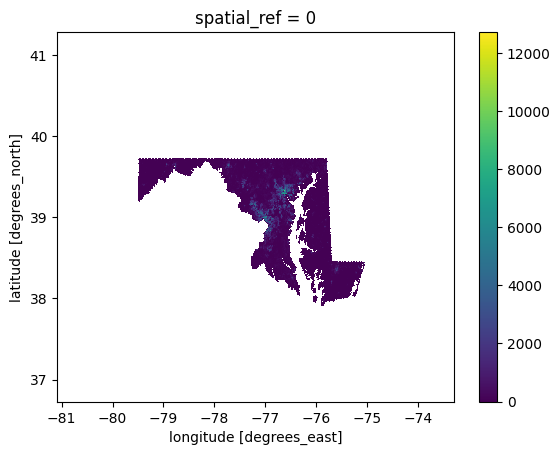

In [120]:
pop.rio.reproject("EPSG:4326").plot()

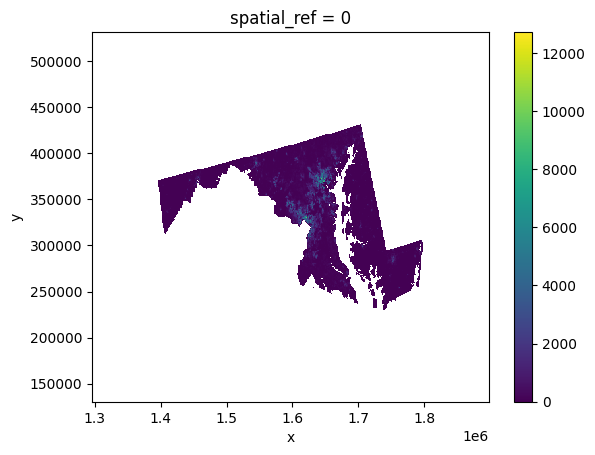

In [121]:
pop.plot()

In [122]:
pop_df = pop.rio.reproject("EPSG:4326").to_dataframe(name='population').reset_index().drop(columns=['spatial_ref']).rename(columns={'x': 'longitude', 'y': 'latitude'})
pop_df = pop_df[pop_df.population.notna()]

In [123]:
pop_df

,latitude,longitude,population
112805,39.724827,-79.475489,1.000000
112806,39.724827,-79.465101,0.990902
112807,39.724827,-79.454714,0.976586
112810,39.724827,-79.423551,0.998446
112811,39.724827,-79.413163,0.871945
...,...,...,...
243824,37.917381,-75.891760,0.826383
243825,37.917381,-75.881372,0.000582
243826,37.917381,-75.870984,0.000582
243827,37.917381,-75.860597,0.751747


In [124]:
fname = f"../../../static/data/maryland_population_1km.arrow"
schema = pa.Schema.from_pandas(pop_df, preserve_index=False)
table = pa.Table.from_pandas(pop_df, preserve_index=False)
writer = pa.ipc.new_file(fname, schema)
writer.write(table)
writer.close()

<Axes: xlabel='longitude', ylabel='latitude'>

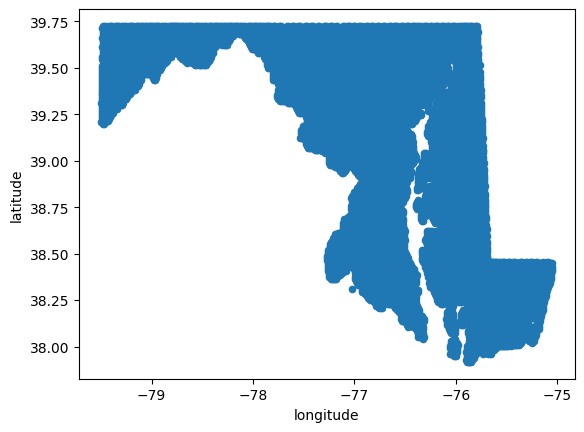

In [116]:
pop_df.plot.scatter(x='longitude', y='latitude')